# 13 · FINAL — robust MILP + refined business rules, with full stress testing

**Final recommendation.** It keeps the brief's limits, the three robust scenarios from notebook 11, and the refined-notebook (07) business rules except one:

| Constraint | Type | Source |
|---|---|---|
| One rate per account, −15% … +25% (1-pt steps) | hard | brief |
| Account retention ≥ 80% | hard | brief |
| 80% ≤ case MLR ≤ 85% | hard | brief |
| Retention ≥ 80% and MLR ≤ 85% under a −3 pt logit lapse shock | robust | nb 11 |
| Retention ≥ 80% and MLR ≤ 85% if the price response is 25% steeper | robust | nb 11 |
| MLR ≤ 85% if claims are 4% higher | robust | nb 11 |
| Premium-weighted retention ≥ 80% | hard | nb 07 |
| Retained average risk score within ±15% of today | hard | nb 07 |
| Top-50 accounts by premium: rate ≤ +15% | hard | nb 07 |
| +25% action penalised at 0.5% of FY2025 premium | soft | nb 07 |
| ~~FY25 MLR > 110% accounts forced into +15…+20%~~ | **dropped** | infeasible with the robust rows, costs ≈$180m; those accounts renew at ~97% even at +25% |

Primary case throughout: FY2025 paid claims carried forward, no trend (README). B4 only in the separate trend scenarios.

> **Use of generative AI (FAQ 9).** Generative AI (Claude, Anthropic) was used to review our v1 pipeline, identify errors in the v1 stress-test arithmetic and the renewal-model price-response specification, and to draft code for the hinge renewal model, the robust MILP and the stress tests. All modelling choices, validation checks, assumptions and the final recommendation were reviewed by the team and are our own.


In [1]:
from pathlib import Path
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA = ROOT / 'data' if (ROOT / 'data').exists() else ROOT   # raw input files
sys.path.insert(0, str(ROOT / 'notebooks'))
from trackA_v2_utils import RATES, solve_rate_mip, portfolio_metrics, RenewalStress, monte_carlo, summarise_mc

M, O = ROOT / 'outputs' / 'v2' / '01_renewal_model', ROOT / 'outputs' / 'v2' / '02_optimisation'
OUT = ROOT / 'outputs' / 'v2' / '04_final_robust_refined'; PL = OUT / 'plots'; PL.mkdir(parents=True, exist_ok=True)
G = np.load(M / 'grid_2026_v2.npz', allow_pickle=True); snap = pd.read_csv(M / 'account_snapshot_2026_v2.csv')
assert (snap['account_id'].to_numpy() == G['account_id']).all()
P, Zg, beta, draws = G['P'], G['Zg'], G['beta'], G['beta_draws']
prem0, claims0, risk, cv = (snap[c].to_numpy() for c in ['annual_premium_2025', 'paid_claims_2025', 'risk_score_2025', 'process_cv'])
N, K = P.shape; i = np.arange(N)
stress = RenewalStress(Zg, beta, G['rate_idx'])
mlr0 = claims0 / prem0; avg_risk = risk.mean()

## 1 · Build and solve (LP bound, then exact MILP)

In [2]:
robust = [dict(name='lapse_shock', P=stress.shift(0.19), claim_mult=1.0, R=0.80, U=0.85),
          dict(name='price_sensitive', P=stress.elastic(1.25), claim_mult=1.0, R=0.80, U=0.85),
          dict(name='claims_up_4pct', P=P, claim_mult=1.04, R=None, U=0.85)]
extra = [('premium_weighted_retention', prem0[:, None] * P, 0.80 * prem0.sum(), np.inf),
         ('risk_mix_upper', P * (risk - 1.15 * avg_risk)[:, None], -np.inf, 0.0),
         ('risk_mix_lower', P * (0.85 * avg_risk - risk)[:, None], -np.inf, 0.0)]
top50 = np.zeros(N, bool); top50[np.argsort(-prem0)[:50]] = True
allowed = np.ones((N, K), bool); allowed[top50[:, None] & (RATES[None, :] > 15)] = False
penalty = 0.005 * prem0[:, None] * (RATES[None, :] == 25)
kw = dict(robust_scenarios=robust, extra_rows=extra, allowed=allowed, objective_penalty=penalty)
x_lp, _, lp_info = solve_rate_mip(P, prem0, claims0, integer=False, **kw)
x, choice, mip_info = solve_rate_mip(P, prem0, claims0, integer=True, **kw)
assert mip_info['solver_status'] == 'Optimal'
diag = pd.DataFrame([{'run': 'LP relaxation (upper bound)', **lp_info}, {'run': 'MILP (decision)', **mip_info}]).drop(columns='constraint_names')
diag.to_csv(OUT / 'solver_diagnostics.csv', index=False); display(diag.round(8))
print(f"LP bound - MILP = ${lp_info['objective'] - mip_info['objective']:,.0f}; objective includes the soft +25% penalty")
np.save(OUT / 'choice_final.npy', choice)

,run,solver_status,runtime_seconds,objective,fractional_accounts,n_coupling_constraints,best_bound,mip_gap
0,LP relaxation (upper bound),Optimal,76.061212,2.572242e+09,1,11,NaN,NaN
1,MILP (decision),Optimal,178.819918,2.572242e+09,0,11,2.572242e+09,7.000000e-08


LP bound - MILP = $177; objective includes the soft +25% penalty


## 2 · Constraint report

In [3]:
fin = portfolio_metrics(choice, P, prem0, claims0); p = P[i, choice]; r = RATES[choice]
mix = np.average(risk, weights=p) / avg_risk - 1
rep = [('Accounts with exactly one rate', N, '= 7,300', True),
       ('Rate range', f'{r.min()}% to {r.max()}%', '-15% to +25%', r.min() >= -15 and r.max() <= 25),
       ('Account retention', fin['account_retention'], '>= 80%', fin['account_retention'] >= .80),
       ('Case MLR', fin['case_mlr'], '80-85%', .80 <= fin['case_mlr'] <= .85),
       ('Premium-weighted retention', fin['premium_weighted_retention'], '>= 80%', fin['premium_weighted_retention'] >= .80),
       ('Retained risk-mix drift', mix, 'within +/-15%', abs(mix) <= .15),
       ('Top-50 accounts above +15%', int((r[top50] > 15).sum()), '= 0', (r[top50] > 15).sum() == 0)]
for s in robust:
    m = portfolio_metrics(choice, s['P'], prem0, claims0, s['claim_mult'])
    if s['R'] is not None: rep.append((f"Retention under {s['name']}", m['account_retention'], '>= 80%', m['account_retention'] >= .7999999))
    rep.append((f"MLR under {s['name']}", m['case_mlr'], '<= 85%', m['case_mlr'] <= .8500001))
rep = pd.DataFrame(rep, columns=['check', 'value', 'limit', 'pass']); rep.to_csv(OUT / 'constraint_report.csv', index=False); display(rep)
assert rep['pass'].all()

,check,value,limit,pass
0,Accounts with exactly one rate,7300,"= 7,300",True
1,Rate range,0% to 25%,-15% to +25%,True
2,Account retention,0.837467,>= 80%,True
3,Case MLR,0.814503,80-85%,True
4,Premium-weighted retention,0.830382,>= 80%,True
5,Retained risk-mix drift,0.022131,within +/-15%,True
6,Top-50 accounts above +15%,0,= 0,True
7,Retention under lapse_shock,0.810785,>= 80%,True
8,MLR under lapse_shock,0.819288,<= 85%,True
9,Retention under price_sensitive,0.8,>= 80%,True


## 3 · Final rate recommendations, rate distribution, segments

In [4]:
rec = snap[['account_id', 'rating_region', 'industry', 'risk_band', 'risk_score_2025', 'covered_lives_2025', 'annual_premium_2025', 'paid_claims_2025']].copy()
rec['fy2025_mlr'] = mlr0
rec['profitability_segment'] = pd.cut(mlr0, [-np.inf, .70, .85, 1.10, 1.50, np.inf], labels=['Star', 'Healthy', 'Marginal-fixable', 'Structural Loss', 'Catastrophic'])
rec['premium_size_segment'] = pd.cut(prem0, [-np.inf, 1e6, 3e6, np.inf], labels=['Small', 'Mid', 'Large'])
rec['top50_account'] = top50
rec['recommended_rate_change_pct'] = r
rec['expected_renewal_probability'] = p
rec['premium_if_renewed'] = prem0 * (1 + r / 100)
rec['projected_2026_premium'] = rec['premium_if_renewed'] * p
rec['projected_2026_paid_claims'] = claims0 * p
rec['projected_case_mlr'] = claims0 / rec['premium_if_renewed']
rec['expected_contribution'] = rec['projected_2026_premium'] - rec['projected_2026_paid_claims']
rec.to_csv(OUT / 'final_rate_recommendations.csv', index=False)
sub = rec[['account_id', 'recommended_rate_change_pct', 'expected_renewal_probability', 'projected_2026_premium', 'projected_2026_paid_claims', 'projected_case_mlr']]
assert len(sub) == 7300 and sub['account_id'].is_unique
sub.to_csv(OUT / 'submission_account_rates.csv', index=False)

rd = rec.groupby('recommended_rate_change_pct').agg(accounts=('account_id', 'size'), fy2025_premium=('annual_premium_2025', 'sum'), fy2025_claims=('paid_claims_2025', 'sum'),
        expected_premium=('projected_2026_premium', 'sum'), expected_claims=('projected_2026_paid_claims', 'sum'), avg_renewal_probability=('expected_renewal_probability', 'mean')).reindex(RATES, fill_value=0)
rd['share_of_accounts'] = rd['accounts'] / N; rd['fy2025_mlr'] = rd['fy2025_claims'] / rd['fy2025_premium'].replace(0, np.nan)
rd['mlr_2026'] = rd['expected_claims'] / rd['expected_premium'].replace(0, np.nan); rd['contribution'] = rd['expected_premium'] - rd['expected_claims']
rd.index.name = 'rate_change_pct'; rd.to_csv(OUT / 'rate_distribution.csv')
bucket = pd.cut(r, [-16, -.5, .5, 5.5, 10.5, 15.5, 20.5, 24.5, 25], labels=['cut', '0%', '+1..5', '+6..10', '+11..15', '+16..20', '+21..24', '+25'])
rb = rec.groupby(bucket, observed=False).agg(accounts=('account_id', 'size'), fy2025_premium=('annual_premium_2025', 'sum'), fy2025_claims=('paid_claims_2025', 'sum'),
        retention=('expected_renewal_probability', 'mean'), contribution=('expected_contribution', 'sum'))
rb['share'] = rb.accounts / N; rb['fy2025_mlr'] = rb.fy2025_claims / rb.fy2025_premium.replace(0, np.nan); rb.to_csv(OUT / 'rate_bucket_summary.csv'); display(rb.round(3))

def seg(by):
    g = rec.groupby(by, observed=True)
    s = g.agg(accounts=('account_id', 'size'), avg_rate=('recommended_rate_change_pct', 'mean'), retention=('expected_renewal_probability', 'mean'),
              fy25_premium=('annual_premium_2025', 'sum'), fy25_claims=('paid_claims_2025', 'sum'), premium_2026=('projected_2026_premium', 'sum'),
              claims_2026=('projected_2026_paid_claims', 'sum'), contribution=('expected_contribution', 'sum'),
              at_25=('recommended_rate_change_pct', lambda v: (v == 25).sum()), held_flat=('recommended_rate_change_pct', lambda v: (v == 0).sum()))
    s['exp_accounts_2026'] = g['expected_renewal_probability'].sum()
    s['fy2025_mlr'] = s.fy25_claims / s.fy25_premium; s['mlr_2026'] = s.claims_2026 / s.premium_2026
    s['account_share_now'] = s.accounts / s.accounts.sum(); s['account_share_2026'] = s.exp_accounts_2026 / s.exp_accounts_2026.sum()
    s['premium_share_now'] = s.fy25_premium / s.fy25_premium.sum(); s['premium_share_2026'] = s.premium_2026 / s.premium_2026.sum()
    return s
segs = {b: seg(b) for b in ['risk_band', 'profitability_segment', 'premium_size_segment', 'industry']}
for b, s in segs.items(): s.to_csv(OUT / f'segment_by_{b}.csv')
display(segs['risk_band'].round(3)); display(segs['profitability_segment'].round(3))
pd.crosstab(rec['recommended_rate_change_pct'], rec['risk_band']).reindex(RATES, fill_value=0).to_csv(OUT / 'rate_distribution_by_risk_band.csv')
pd.Series({**fin, 'retained_risk_mix_drift': mix, 'covered_lives_retention': (p * rec.covered_lives_2025).sum() / rec.covered_lives_2025.sum(),
           'fy2025_case_mlr': claims0.sum() / prem0.sum(), 'mlr_points_improvement': 100 * (claims0.sum() / prem0.sum() - fin['case_mlr'])}).to_csv(OUT / 'portfolio_summary.csv', header=['value'])

,accounts,fy2025_premium,fy2025_claims,retention,contribution,share,fy2025_mlr
cut,0,0.000000e+00,0.000000e+00,NaN,0.000000e+00,0.000,NaN
0%,1156,1.761284e+09,4.479868e+08,0.854,1.114512e+09,0.158,0.254
+1..5,1279,2.308988e+09,7.988438e+08,0.863,1.351942e+09,0.175,0.346
+6..10,1807,3.751330e+09,1.894270e+09,0.840,1.805747e+09,0.248,0.505
+11..15,877,2.223181e+09,1.723668e+09,0.820,5.967391e+08,0.120,0.775
+16..20,430,8.874325e+08,7.047005e+08,0.785,2.668979e+08,0.059,0.794
+21..24,540,1.327704e+09,1.318005e+09,0.723,2.328158e+08,0.074,0.993
+25,1211,2.740081e+09,6.417526e+09,0.872,-2.782712e+09,0.166,2.342


,accounts,avg_rate,retention,fy25_premium,fy25_claims,premium_2026,claims_2026,contribution,at_25,held_flat,exp_accounts_2026,fy2025_mlr,mlr_2026,account_share_now,account_share_2026,premium_share_now,premium_share_2026
risk_band,,,,,,,,,,,,,,,,,
0.15–0.49,1680,0.730,0.857,3.127618e+09,8.444569e+08,2.693953e+09,7.190275e+08,1.974925e+09,0,1106,1439.059,0.27,0.267,0.230,0.235,0.209,0.193
0.50–0.99,3340,8.084,0.837,6.690000e+09,3.545700e+09,6.017181e+09,2.908562e+09,3.108619e+09,0,50,2796.105,0.53,0.483,0.458,0.457,0.446,0.432
1.00–1.49,1080,20.129,0.758,2.355000e+09,2.190150e+09,2.114704e+09,1.609291e+09,5.054131e+08,70,0,818.875,0.93,0.761,0.148,0.134,0.157,0.152
1.50–2.49,760,24.809,0.833,1.725000e+09,2.932500e+09,1.789932e+09,2.443864e+09,-6.539314e+08,709,0,633.167,1.70,1.365,0.104,0.104,0.115,0.128
2.50–5.00,440,24.818,0.969,1.102382e+09,3.792193e+09,1.324819e+09,3.673903e+09,-2.349084e+09,432,0,426.303,3.44,2.773,0.060,0.070,0.073,0.095


,accounts,avg_rate,retention,fy25_premium,fy25_claims,premium_2026,claims_2026,contribution,at_25,held_flat,exp_accounts_2026,fy2025_mlr,mlr_2026,account_share_now,account_share_2026,premium_share_now,premium_share_2026
profitability_segment,,,,,,,,,,,,,,,,,
Star,4695,5.288,0.849,9.388212e+09,4.019855e+09,8.358928e+09,3.352873e+09,5.006055e+09,0,1155,3986.262,0.428,0.401,0.643,0.652,0.626,0.600
Healthy,632,13.959,0.800,1.207270e+09,9.296313e+08,1.090893e+09,7.243744e+08,3.665184e+08,0,1,505.719,0.770,0.664,0.087,0.083,0.080,0.078
Marginal-fixable,567,20.134,0.746,1.224459e+09,1.176449e+09,1.080992e+09,8.523644e+08,2.286274e+08,3,0,422.899,0.961,0.789,0.078,0.069,0.082,0.078
Structural Loss,397,24.131,0.768,8.543408e+08,1.110713e+09,8.231675e+08,8.659942e+08,-4.282671e+07,220,0,304.711,1.300,1.052,0.054,0.050,0.057,0.059
Catastrophic,1009,24.872,0.886,2.325718e+09,6.068351e+09,2.586609e+09,5.559041e+09,-2.972432e+09,988,0,893.917,2.609,2.149,0.138,0.146,0.155,0.186


## 4 · Comparison with every earlier solution (all scored on the same v2 curve)

In [5]:
sols = {}
for name, path in [('v1 nb06 heuristic', ROOT / 'outputs' / 'New_optimisation' / 'final_rate_recommendations.csv'),
                   ('v1 nb07 refined heuristic', ROOT / 'outputs' / 'refined optimisation' / 'refined_rate_recommendations.csv')]:
    if path.exists():
        v1 = pd.read_csv(path).set_index('account_id').reindex(snap['account_id'])
        sols[name] = np.searchsorted(RATES, v1['selected_rate_change_pct'].to_numpy().astype(int))
sols['v2 nominal MILP'] = np.load(O / 'choice_nominal.npy'); sols['v2 robust MILP'] = np.load(O / 'choice_robust.npy'); sols['FINAL v2 robust + refined'] = choice
sols = {k: v for k, v in sols.items()}
comp = []
for name, ch in sols.items():
    m = portfolio_metrics(ch, P, prem0, claims0); pp = P[i, ch]
    comp.append({'solution': name, **m, 'risk_mix_drift': np.average(risk, weights=pp) / avg_risk - 1, 'top50_above_15': int((RATES[ch][top50] > 15).sum())})
comp = pd.DataFrame(comp); comp.to_csv(OUT / 'solution_comparison.csv', index=False)
display(comp[['solution', 'expected_contribution', 'account_retention', 'premium_weighted_retention', 'case_mlr', 'risk_mix_drift', 'avg_rate_premium_weighted', 'accounts_at_cap', 'top50_above_15']].round(4))

,solution,expected_contribution,account_retention,premium_weighted_retention,case_mlr,risk_mix_drift,avg_rate_premium_weighted,accounts_at_cap,top50_above_15
0,v1 nb06 heuristic,2.607244e+09,0.7989,0.7974,0.8087,0.0315,14.2044,2041,19
1,v1 nb07 refined heuristic,2.377788e+09,0.8013,0.8045,0.8258,0.0438,13.3259,56,0
2,v2 nominal MILP,2.636389e+09,0.8071,0.8100,0.8087,0.0308,13.5736,1825,19
3,v2 robust MILP,2.612325e+09,0.8375,0.8292,0.8126,0.0215,12.1854,1504,19
4,FINAL v2 robust + refined,2.585942e+09,0.8375,0.8304,0.8145,0.0221,12.0398,1211,0


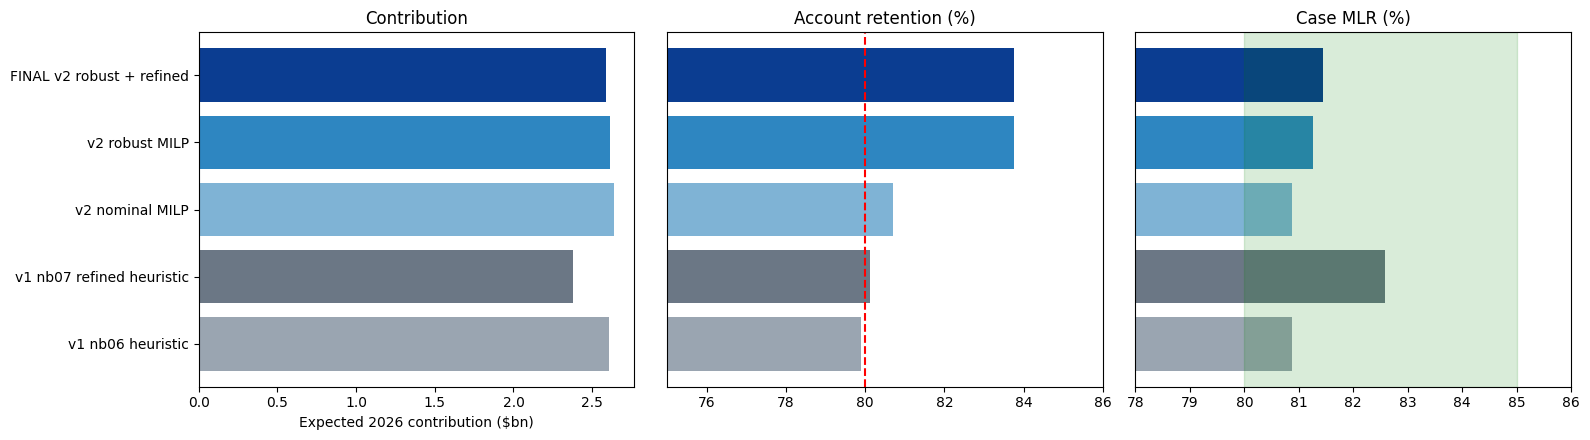

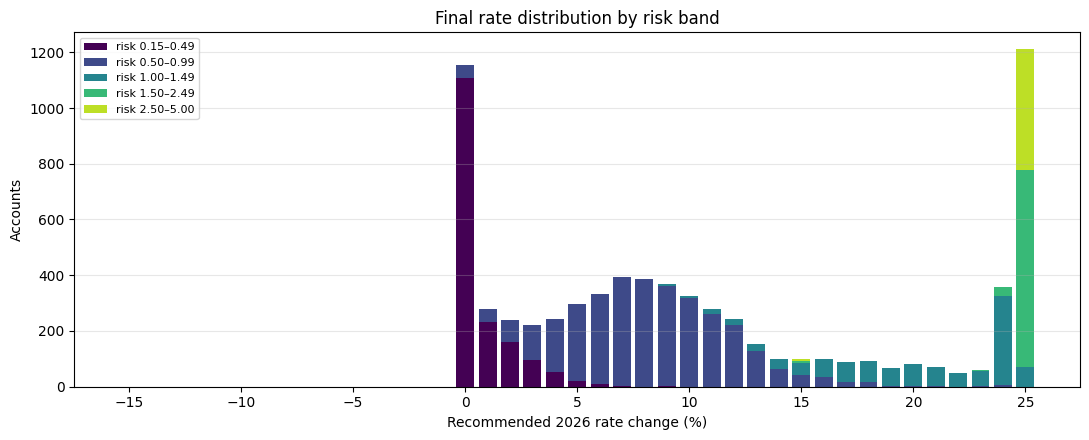

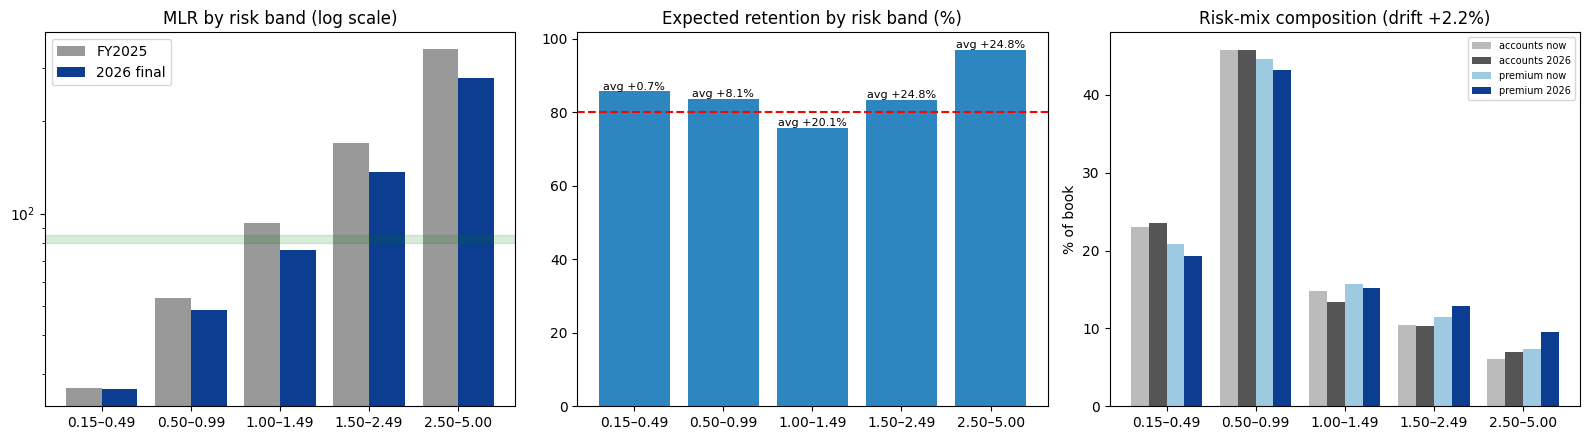

In [6]:
colors = ['#9aa5b1', '#6b7785', '#7fb3d5', '#2e86c1', '#0b3d91']
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5)); names = comp['solution']
ax[0].barh(names, comp['expected_contribution'] / 1e9, color=colors); ax[0].set_xlabel('Expected 2026 contribution ($bn)'); ax[0].set_title('Contribution')
ax[1].barh(names, 100 * comp['account_retention'], color=colors); ax[1].axvline(80, color='r', ls='--'); ax[1].set_xlim(75, 86); ax[1].set_title('Account retention (%)'); ax[1].set_yticks([])
ax[2].barh(names, 100 * comp['case_mlr'], color=colors); ax[2].axvspan(80, 85, color='g', alpha=.15); ax[2].set_xlim(78, 86); ax[2].set_title('Case MLR (%)'); ax[2].set_yticks([])
fig.tight_layout(); fig.savefig(PL / '01_solution_comparison.png', dpi=170); plt.show()

rdb = pd.read_csv(OUT / 'rate_distribution_by_risk_band.csv', index_col=0)
fig, ax = plt.subplots(figsize=(11, 4.5)); bottom = np.zeros(len(rdb))
for col, c in zip(rdb.columns, plt.cm.viridis(np.linspace(0, .9, rdb.shape[1]))):
    ax.bar(rdb.index, rdb[col], bottom=bottom, color=c, label=f'risk {col}'); bottom += rdb[col].to_numpy()
ax.set_xlabel('Recommended 2026 rate change (%)'); ax.set_ylabel('Accounts'); ax.set_title('Final rate distribution by risk band'); ax.legend(fontsize=8); ax.grid(axis='y', alpha=.3)
fig.tight_layout(); fig.savefig(PL / '02_rate_distribution_by_risk_band.png', dpi=170); plt.show()

sb = segs['risk_band']; xb = np.arange(len(sb))
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
ax[0].bar(xb - .2, 100 * sb.fy2025_mlr, .4, color='#999', label='FY2025'); ax[0].bar(xb + .2, 100 * sb.mlr_2026, .4, color='#0b3d91', label='2026 final')
ax[0].axhspan(80, 85, color='g', alpha=.15); ax[0].set_yscale('log'); ax[0].set_xticks(xb, sb.index); ax[0].set_title('MLR by risk band (log scale)'); ax[0].legend()
ax[1].bar(xb, 100 * sb.retention, color='#2e86c1'); ax[1].axhline(80, color='r', ls='--'); ax[1].set_xticks(xb, sb.index); ax[1].set_title('Expected retention by risk band (%)')
for j, v in enumerate(sb.avg_rate): ax[1].text(j, 100 * sb.retention.iloc[j] + .5, f'avg {v:+.1f}%', ha='center', fontsize=8)
w = .2
ax[2].bar(xb - 1.5 * w, 100 * sb.account_share_now, w, label='accounts now', color='#bbb'); ax[2].bar(xb - .5 * w, 100 * sb.account_share_2026, w, label='accounts 2026', color='#555')
ax[2].bar(xb + .5 * w, 100 * sb.premium_share_now, w, label='premium now', color='#9ecae1'); ax[2].bar(xb + 1.5 * w, 100 * sb.premium_share_2026, w, label='premium 2026', color='#0b3d91')
ax[2].set_xticks(xb, sb.index); ax[2].set_title(f'Risk-mix composition (drift {mix:+.1%})'); ax[2].set_ylabel('% of book'); ax[2].legend(fontsize=7)
fig.tight_layout(); fig.savefig(PL / '03_segments_mlr_retention_mix.png', dpi=170); plt.show()

## 5 · Stress testing the final rates (fixed rates, corrected arithmetic)
Premium **and** claims are re-weighted by the stressed renewal probability; lapse shocks are logit shifts sized to the v1 averages (−2/−3/−5 pts at the v2 nominal solution) so healthy, price-sensitive accounts leave first; B4 claims are multiplied by renewal probability.

In [7]:
b4 = pd.read_csv(DATA / 'B4_regional_macro_benchmarks.csv.gz').query('calendar_year == 2026').set_index('rating_region')
trend = ((1 + b4['medical_cost_inflation_pct'] / 100) * (1 + b4['utilization_trend_pct'] / 100)).reindex(snap['rating_region']).to_numpy()
ref = sols['v2 nominal MILP']
d2, d3, d5 = (stress.delta_for_drop(ref, v) for v in (.02, .03, .05)); fav = stress.delta_for_drop(ref, -.02)
low = (risk < 1.0)[:, None]
SCEN = [('Favorable', stress.shift(fav), .95, 'combined'), ('Mild favorable', stress.shift(fav), 1.0, 'combined'), ('Base', P, 1.0, 'base'),
        ('Mild adverse', stress.shift(d2), 1.05, 'combined'), ('Moderate adverse', stress.shift(d3), 1.05, 'combined'), ('Severe adverse', stress.shift(d5), 1.10, 'combined'),
        ('Lapse shock only (-3 pts)', stress.shift(d3), 1.0, 'renewal'), ('Price response +25%', stress.elastic(1.25), 1.0, 'renewal'),
        ('Adverse selection (risk<1.0 lapse)', np.where(low, stress.shift(0.35), P), 1.0, 'renewal'),
        ('Claims +4% only', P, 1.04, 'claims'), ('Claims +5% only', P, 1.05, 'claims'),
        ('B4 trend, rates not reloaded', P, trend, 'B4 (separate)'), ('Combined severe (B4 + -5 pts)', stress.shift(d5), trend, 'B4 (separate)')]
order = [s[0] for s in SCEN]; rows = []
for sol, ch in sols.items():
    for sc, Ps, cm, fam in SCEN:
        m = portfolio_metrics(ch, Ps, prem0, claims0, cm)
        rows.append(dict(solution=sol, scenario=sc, family=fam, **m, retention_pass=m['account_retention'] >= .80,
                         prem_retention_pass=m['premium_weighted_retention'] >= .80, mlr_corridor_pass=.80 <= m['case_mlr'] <= .85, mlr_ceiling_pass=m['case_mlr'] <= .85))
det = pd.DataFrame(rows); det['limits_met'] = det.retention_pass & det.mlr_ceiling_pass; det.to_csv(OUT / 'stress_deterministic.csv', index=False)
final_tbl = det[det.solution == 'FINAL v2 robust + refined'].set_index('scenario').loc[order, ['family', 'account_retention', 'premium_weighted_retention', 'case_mlr', 'expected_contribution', 'retention_pass', 'mlr_corridor_pass', 'mlr_ceiling_pass']]
final_tbl.to_csv(OUT / 'stress_final_solution.csv'); display(final_tbl.round(4))
score = det[det.family != 'B4 (separate)'].groupby('solution')['limits_met'].agg(['sum', 'size']).rename(columns={'sum': 'primary scenarios meeting retention>=80% & MLR<=85%', 'size': 'of'})
score = score.reindex(list(sols)); score.to_csv(OUT / 'stress_pass_count.csv'); display(score)

,family,account_retention,premium_weighted_retention,case_mlr,expected_contribution,retention_pass,mlr_corridor_pass,mlr_ceiling_pass
scenario,,,,,,,,
Favorable,combined,0.8550,0.8485,0.7710,3.262927e+09,True,False,True
Mild favorable,combined,0.8550,0.8485,0.8115,2.684878e+09,True,True,True
Base,base,0.8375,0.8304,0.8145,2.585942e+09,True,True,True
Mild adverse,combined,0.8198,0.8121,0.8585,1.928845e+09,True,False,False
Moderate adverse,combined,0.8109,0.8030,0.8602,1.883896e+09,True,False,False
Severe adverse,combined,0.7929,0.7845,0.9049,1.251776e+09,False,False,False
Lapse shock only (-3 pts),renewal,0.8109,0.8030,0.8193,2.436059e+09,True,True,True
Price response +25%,renewal,0.8000,0.7884,0.8075,2.539264e+09,True,True,True
Adverse selection (risk<1.0 lapse),renewal,0.8022,0.7954,0.8304,2.268791e+09,True,True,True


,primary scenarios meeting retention>=80% & MLR<=85%,of
solution,,
v1 nb06 heuristic,2,11
v1 nb07 refined heuristic,3,11
v2 nominal MILP,5,11
v2 robust MILP,7,11
FINAL v2 robust + refined,7,11


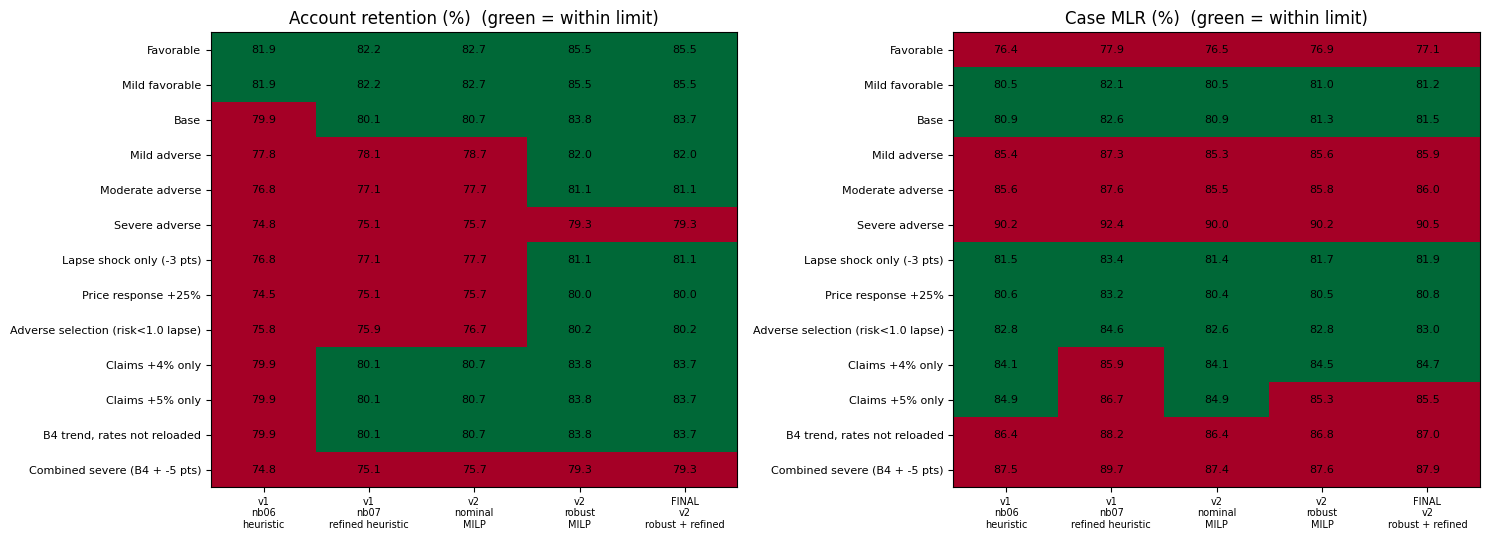

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
for a, col, lim, title in [(ax[0], 'account_retention', (.80, None), 'Account retention (%)'), (ax[1], 'case_mlr', (.80, .85), 'Case MLR (%)')]:
    t = det.pivot(index='scenario', columns='solution', values=col).reindex(order)[list(sols)]
    ok = (t >= lim[0]) & ((t <= lim[1]) if lim[1] else True)
    a.imshow(ok.to_numpy().astype(float), cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
    for (yy, xx), v in np.ndenumerate(t.to_numpy()): a.text(xx, yy, f'{100 * v:.1f}', ha='center', va='center', fontsize=8)
    a.set_xticks(range(t.shape[1]), [c.replace(' ', '\n', 2) for c in t.columns], fontsize=7); a.set_yticks(range(len(order)), order, fontsize=8); a.set_title(title + '  (green = within limit)')
fig.tight_layout(); fig.savefig(PL / '04_stress_heatmap.png', dpi=170); plt.show()

## 6 · Breakpoints and Monte Carlo

,solution,base_retention,base_mlr,max_claims_increase_before_85pct,retention_headroom_pts,max_logit_lapse_shock,max_price_sensitivity_multiple
0,v1 nb06 heuristic,0.7989,0.8087,0.0510,-0.1071,NaN,NaN
1,v1 nb07 refined heuristic,0.8013,0.8258,0.0293,0.1338,0.00,1.00
2,v2 nominal MILP,0.8071,0.8087,0.0511,0.7133,0.04,1.02
3,v2 robust MILP,0.8375,0.8126,0.0461,3.7517,0.26,1.24
4,FINAL v2 robust + refined,0.8375,0.8145,0.0436,3.7467,0.26,1.24


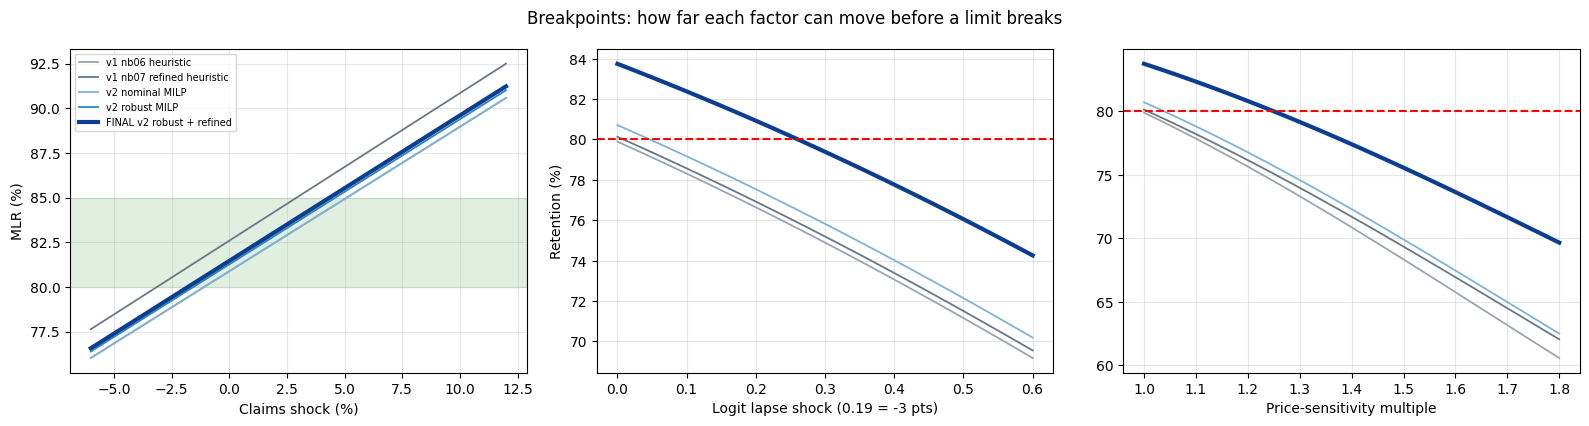

In [9]:
cg, dg, eg = np.round(np.arange(.94, 1.1201, .005), 3), np.arange(0, .61, .01), np.round(np.arange(1, 1.81, .02), 2)
bp, curves = [], {}
for sol, ch in sols.items():
    base = portfolio_metrics(ch, P, prem0, claims0)
    mc_ = np.array([portfolio_metrics(ch, P, prem0, claims0, c)['case_mlr'] for c in cg])
    rd_ = np.array([stress.shift(d)[i, ch].mean() for d in dg]); re_ = np.array([stress.elastic(k)[i, ch].mean() for k in eg])
    curves[sol] = (mc_, rd_, re_)
    bp.append(dict(solution=sol, base_retention=base['account_retention'], base_mlr=base['case_mlr'],
                   max_claims_increase_before_85pct=.85 / base['case_mlr'] - 1, retention_headroom_pts=100 * (base['account_retention'] - .80),
                   max_logit_lapse_shock=dg[rd_ >= .80].max() if (rd_ >= .80).any() else np.nan,
                   max_price_sensitivity_multiple=eg[re_ >= .80].max() if (re_ >= .80).any() else np.nan))
bp = pd.DataFrame(bp); bp.to_csv(OUT / 'stress_breakpoints.csv', index=False); display(bp.round(4))
fig, ax = plt.subplots(1, 3, figsize=(16, 4.3))
for (sol, (mc_, rd_, re_)), c in zip(curves.items(), colors):
    lw = 3 if sol.startswith('FINAL') else 1.3
    ax[0].plot(100 * (cg - 1), 100 * mc_, color=c, lw=lw, label=sol); ax[1].plot(dg, 100 * rd_, color=c, lw=lw); ax[2].plot(eg, 100 * re_, color=c, lw=lw)
ax[0].axhspan(80, 85, color='g', alpha=.12); ax[0].set_xlabel('Claims shock (%)'); ax[0].set_ylabel('MLR (%)'); ax[0].legend(fontsize=7)
ax[1].axhline(80, color='r', ls='--'); ax[1].set_xlabel('Logit lapse shock (0.19 = -3 pts)'); ax[1].set_ylabel('Retention (%)')
ax[2].axhline(80, color='r', ls='--'); ax[2].set_xlabel('Price-sensitivity multiple')
for a in ax: a.grid(alpha=.3)
fig.suptitle('Breakpoints: how far each factor can move before a limit breaks'); fig.tight_layout(); fig.savefig(PL / '05_breakpoints.png', dpi=170); plt.show()

,solution,sims,retention_mean,retention_p05,mlr_mean,mlr_p05,mlr_p95,contribution_mean,contribution_p05,prob_retention_ok,prob_mlr_ok,prob_all_limits_ok
0,v1 nb06 heuristic,3000,0.7973,0.7864,0.8086,0.8002,0.8165,2.603064e+09,2.480358e+09,0.3563,0.9543,0.3450
1,v1 nb07 refined heuristic,3000,0.7999,0.7900,0.8260,0.8189,0.8332,2.370554e+09,2.254452e+09,0.5000,1.0000,0.5000
2,v2 nominal MILP,3000,0.8056,0.7949,0.8085,0.8004,0.8163,2.632765e+09,2.513558e+09,0.8050,0.9560,0.7747
3,v2 robust MILP,3000,0.8361,0.8262,0.8124,0.8044,0.8200,2.609508e+09,2.493641e+09,1.0000,0.9923,0.9923
4,FINAL v2 robust + refined,3000,0.8360,0.8263,0.8144,0.8065,0.8218,2.582625e+09,2.467432e+09,1.0000,0.9977,0.9977


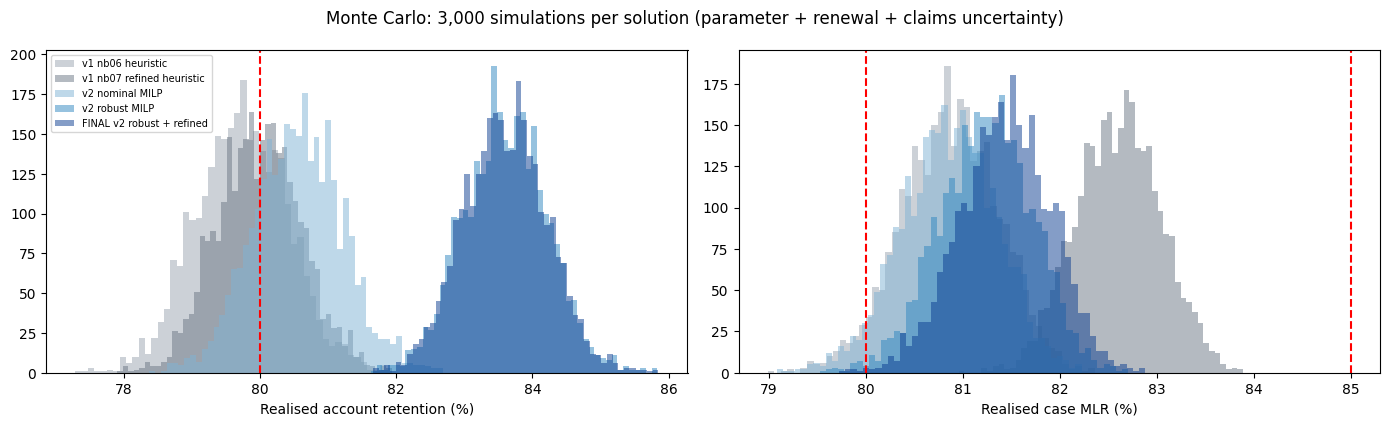

In [10]:
mc_rows, mc_draws = [], {}
for sol, ch in sols.items():
    rr = monte_carlo(ch, Zg, draws, prem0, claims0, cv, n_bern=10, seed=11); mc_draws[sol] = rr
    rr2 = rr.assign(ok=(rr.account_retention >= .8) & rr.case_mlr.between(.8, .85))
    mc_rows.append({'solution': sol, **summarise_mc(rr)})
mc = pd.DataFrame(mc_rows); mc.to_csv(OUT / 'stress_monte_carlo.csv', index=False); display(mc.round(4))
fig, ax = plt.subplots(1, 2, figsize=(14, 4.3))
for (sol, rr), c in zip(mc_draws.items(), colors):
    ax[0].hist(100 * rr.account_retention, bins=50, alpha=.5, color=c, label=sol); ax[1].hist(100 * rr.case_mlr, bins=50, alpha=.5, color=c)
ax[0].axvline(80, color='r', ls='--'); ax[0].set_xlabel('Realised account retention (%)'); ax[0].legend(fontsize=7)
ax[1].axvline(80, color='r', ls='--'); ax[1].axvline(85, color='r', ls='--'); ax[1].set_xlabel('Realised case MLR (%)')
fig.suptitle('Monte Carlo: 3,000 simulations per solution (parameter + renewal + claims uncertainty)'); fig.tight_layout(); fig.savefig(PL / '06_monte_carlo.png', dpi=170); plt.show()

In [11]:
fr = rec.set_index('recommended_rate_change_pct')
readme = f"""# FINAL Track A recommendation - v2 robust MILP + refined business rules

## Portfolio (primary case: FY2025 claims carried forward, no trend)
{pd.read_csv(OUT / 'portfolio_summary.csv').to_string(index=False)}

## Solver
{diag[['run', 'solver_status', 'objective', 'runtime_seconds', 'fractional_accounts']].to_string(index=False)}

## Constraint report
{rep.to_string(index=False)}

## Comparison (all on the v2 renewal curve)
{comp[['solution', 'expected_contribution', 'account_retention', 'premium_weighted_retention', 'case_mlr', 'risk_mix_drift']].round(4).to_string(index=False)}

## Stress: primary scenarios meeting both limits
{score.to_string()}

## Final solution stress table
{final_tbl.round(4).to_string()}

## Breakpoints
{bp.round(4).to_string(index=False)}

## Monte Carlo
{mc.round(4).to_string(index=False)}

Note: the +10% claims 'Severe adverse' and B4-trend scenarios cannot be met by any rate set inside a 5-pt corridor while holding the 80% floor at base; they are re-pricing triggers, not pricing failures.
"""
(OUT / 'README_final.md').write_text(readme, encoding='utf-8'); print(sorted(p.name for p in OUT.iterdir()))

['README_final.md', 'choice_final.npy', 'constraint_report.csv', 'final_rate_recommendations.csv', 'plots', 'portfolio_summary.csv', 'rate_bucket_summary.csv', 'rate_distribution.csv', 'rate_distribution_by_risk_band.csv', 'segment_by_industry.csv', 'segment_by_premium_size_segment.csv', 'segment_by_profitability_segment.csv', 'segment_by_risk_band.csv', 'solution_comparison.csv', 'solver_diagnostics.csv', 'stress_breakpoints.csv', 'stress_deterministic.csv', 'stress_final_solution.csv', 'stress_monte_carlo.csv', 'stress_pass_count.csv', 'submission_account_rates.csv']
